# orchestration example

In [44]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama


In [45]:
### 容器，node里面的variable都必须在这里定义
class State(TypedDict):
    text: str
    category: str
    draft: str
    final: str

In [46]:
llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0
)

# node 1 : categorize input content into 3 categories

In [47]:
def node1_classify(state: State):
    prompt = f"""
    Classify the following text into exactly one category:

    news
    email
    other

    Return only the category name.

    Text:
    {state["text"]}
    """

    response = llm.invoke(prompt)

    category = response.content.strip().lower()

    return {"category": category}

# node 2 summarize news

In [48]:
def node2_summarize_news(state: State):
    prompt = f"""
    Summarize this news article concisely.

    Focus on:
    - key event
    - important people or companies
    - business impact

    Text:
    {state["text"]}
    """

    response = llm.invoke(prompt)

    return {"draft": response.content}

# node 3 summarize emails

In [49]:
def node3_summarize_email(state: State):
    prompt = f"""
    Summarize this email.

    Requirements: 
    output shall contain:
    - sender's name
    - receipt's name
    - sender's main message
    - requested action
    - any deadline

    Text:
    {state["text"]}
    """

    response = llm.invoke(prompt)

    return {"draft": response.content}

# node 4 summarize other text

In [50]:
def node4_summarize_general(state: State):
    prompt = f"""
    Summarize the following text clearly and concisely.

    Text:
    {state["text"]}
    """

    response = llm.invoke(prompt)

    return {"draft": response.content}

# routing

In [51]:
## 读取第一个 LLM 的结果， 决定 LangGraph 下一步走哪个 node
def routing(state: State):
    category = state["category"]   ##input

    if "news" in category:
        return "news"

    elif "email" in category:
        return "email"

    else:
        return "other"

# node 5, reviewer 

In [52]:
def node5_review(state: State):
    prompt = f"""
    Improve the following summary.

    Make sure it is:
    - accurate
    - concise
    - easy to understand

    Original text:
    {state["text"]}

    Draft summary:
    {state["draft"]}

    Return only the improved summary.
    """

    response = llm.invoke(prompt)

    return {"final": response.content}

# connecting graph

In [53]:
builder = StateGraph(State)

builder.add_node("node1_classify", node1_classify)
builder.add_node("node2_summarize_news", node2_summarize_news)
builder.add_node("node3_summarize_email", node3_summarize_email)
builder.add_node("node4_summarize_general", node4_summarize_general)
builder.add_node("node5_review", node5_review)



builder.add_edge(START,"node1_classify")
builder.add_conditional_edges("node1_classify",
                              routing,
                              {
                                  "news": "node2_summarize_news",
                                  "email": "node3_summarize_email",
                                  "other": "node4_summarize_general",
                              }
                              )

builder.add_edge("node2_summarize_news","node5_review")
builder.add_edge("node3_summarize_email","node5_review")
builder.add_edge("node4_summarize_general","node5_review")
builder.add_edge("node5_review",END)

graph = builder.compile()

In [65]:
# RUN EXAMPLE
result = graph.invoke({
    "text": """
   Hi Sarah,

    Please review the Q3 credit risk results.
    Delinquency increased by 8%.
    Please send your analysis by Friday.

    Thanks,
    John
    """,
    "category": "",
    "draft": "",
    "final": ""
})

print(result)

{'text': '\n   Hi Sarah,\n\n    Please review the Q3 credit risk results.\n    Delinquency increased by 8%.\n    Please send your analysis by Friday.\n\n    Thanks,\n    John\n    ', 'category': 'other', 'draft': 'Here is a clear and concise summary of the text:\n\nJohn is asking Sarah to review the Q3 credit risk results, which show an 8% increase in delinquency. He needs her analysis by Friday.', 'final': 'Here is the improved summary:\n\nJohn is asking Sarah to review Q3 credit risk results, which show an 8% increase in delinquency, and needs her analysis by Friday.'}


In [66]:
print('draft:'+ result['draft'])
print('final:'+ result['final'])

draft:Here is a clear and concise summary of the text:

John is asking Sarah to review the Q3 credit risk results, which show an 8% increase in delinquency. He needs her analysis by Friday.
final:Here is the improved summary:

John is asking Sarah to review Q3 credit risk results, which show an 8% increase in delinquency, and needs her analysis by Friday.


In [67]:
for step in graph.stream(result):
    print("Executed node:", list(step.keys())[0])

Executed node: node1_classify
Executed node: node4_summarize_general
Executed node: node5_review


In [56]:
## remove review step
builder = StateGraph(State)

builder.add_node("node1_classify", node1_classify)
builder.add_node("node2_summarize_news", node2_summarize_news)
builder.add_node("node3_summarize_email", node3_summarize_email)
builder.add_node("node4_summarize_general", node4_summarize_general)
builder.add_node("node5_review", node5_review)



builder.add_edge(START,"node1_classify")
builder.add_conditional_edges("node1_classify",
                              routing,
                              {
                                  "news": "node2_summarize_news",
                                  "email": "node3_summarize_email",
                                  "other": "node4_summarize_general",
                              }
                              )

builder.add_edge("node2_summarize_news",END)
builder.add_edge("node3_summarize_email",END)
builder.add_edge("node4_summarize_general",END)


graph2 = builder.compile()

In [59]:
# RUN EXAMPLE
result = graph2.invoke({
    "text": """
Hi siyi,

We have a new Handshake AI project we think you’d be a fit for. You’re receiving this because Handshake AI invites experts across many fields to help improve how AI models reason.

On Project Planck (Math), you’ll write advanced scientific questions with single, specific answers, designed to stump frontier AI models. You’ll work remotely on your own schedule. Training is provided, so no prior AI or technical experience is needed.

Accept invite
Select “Accept invite” for full details and to begin onboarding. Once you’re onboarded, you can start earning on tasks.

Set yourself up for success: join a live 30-minute onboarding session for a walkthrough, best practices, and a chance to ask questions. There are two session times — join whichever one works for your schedule.

Time — IST / PT
(India / US Pacific)	Days
6:30pm / 6:00am	Tue, Thu
9:30pm / 9:00am	Tue, Thu, Sat
6:30pm IST / 6:00am PT — Join here → · Add to Google Calendar →

9:30pm IST / 9:00am PT — Join here → · Add to Google Calendar →

In UTC: 6:30pm IST is 1:00pm, 9:30pm IST is 4:00pm. Adding to your calendar converts the time to your local zone automatically.

Best,
The Handshake AI Team
""",
    "category": "",
    "draft": ""
#     "final": ""
})

print('draft:'+ result['draft'])

draft:Here is a clear and concise summary of the text:

The Handshake AI team is inviting you to participate in a new project called Project Planck, where you'll write advanced scientific questions to challenge AI models. You'll work remotely on your own schedule and receive training. To get started, join a 30-minute onboarding session at one of two scheduled times: Tuesday or Thursday, 6:30pm or 9:30pm IST/PT.


In [61]:
for step in graph2.stream(result):
    print("Executed node:", list(step.keys())[0])

Executed node: node1_classify
Executed node: node4_summarize_general


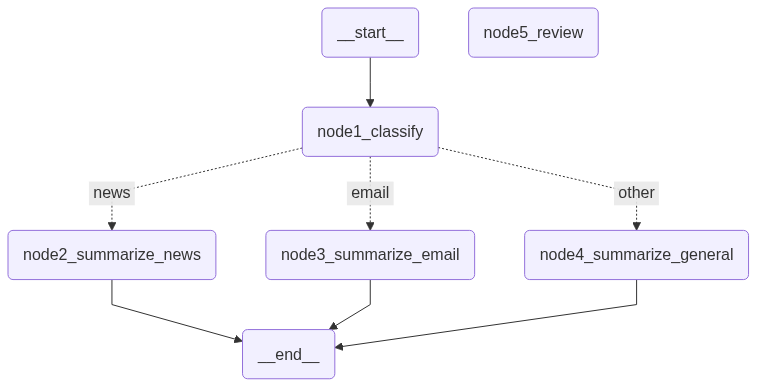

In [62]:
from IPython.display import Image, display

display(
    Image(
        graph2.get_graph().draw_mermaid_png()
    )
)